# 🏠 House Price Prediction with Machine Learning

**Author**: Avinash Kumar Pal  
**Domain**: Real Estate Analytics & Predictive Machine Learning  

---

## 📌 Executive Summary & Architecture
This project builds an end-to-end Machine Learning system for real estate valuation. It includes missing value imputation, domain feature engineering, correlation analysis, multi-model cross-validation (`LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`, `RandomForestRegressor`, `GradientBoostingRegressor`), residual homoscedasticity evaluation, automated model artifact serialization (`joblib`), CLI tooling (`train.py`, `predict.py`), FastAPI server backend (`app_api.py`), and an interactive web application dashboard.

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from src.data import load_dataset, clean_missing_values
from src.features import engineer_features
from src.models import train_and_evaluate_all, HousePriceModel
from src.evaluation import compute_regression_metrics, evaluate_residuals, get_feature_importances

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries and modular package imported successfully!')

Libraries and modular package imported successfully!


In [2]:
df_raw = load_dataset('House_Price_Data.csv')
print(f'Dataset Loaded Shape: {df_raw.shape}')
display(df_raw.head())

Dataset Loaded Shape: (1500, 10)


,Area_SqFt,Bedrooms,Bathrooms,Stories,House_Age_Years,Garage_Cars,Neighborhood,Furnishing,Has_Pool,Price
0,2248.4,3,2,3,4.0,2,Suburbs,Semi-Furnished,No,486568.02
1,1930.9,4,2,2,22.0,2,Suburbs,Unfurnished,No,462908.03
2,2323.8,3,4,2,8.0,1,Downtown,Furnished,Yes,667473.07
3,2761.5,2,4,2,28.0,2,Downtown,Unfurnished,Yes,675287.95
4,1882.9,2,2,1,15.0,0,Suburbs,Semi-Furnished,No,371389.68


In [3]:
print('--- Null Values Count ---')
print(df_raw.isnull().sum())
print('\n--- Statistical Summary ---')
display(df_raw.describe())

--- Null Values Count ---
Area_SqFt          25
Bedrooms            0
Bathrooms           0
Stories             0
House_Age_Years    15
Garage_Cars         0
Neighborhood        0
Furnishing          0
Has_Pool            0
Price               0
dtype: int64

--- Statistical Summary ---


,Area_SqFt,Bedrooms,Bathrooms,Stories,House_Age_Years,Garage_Cars,Price
count,1475.000000,1500.000000,1500.000000,1500.000000,1485.000000,1500.000000,1500.000000
mean,2021.468271,3.096667,2.163333,1.601333,23.969697,1.618000,492775.860000
std,494.634370,0.981137,0.865537,0.669351,14.321765,0.796973,83959.123117
min,600.000000,1.000000,1.000000,1.000000,0.000000,0.000000,196752.260000
25%,1686.850000,3.000000,2.000000,1.000000,12.000000,1.000000,435279.632500
50%,2023.500000,3.000000,2.000000,1.000000,23.000000,2.000000,490540.380000
75%,2335.700000,4.000000,3.000000,2.000000,36.000000,2.000000,545475.985000
max,3926.400000,5.000000,4.000000,3.000000,49.000000,3.000000,742765.180000


In [4]:
df_clean, imp_values = clean_missing_values(df_raw)
print(f'Imputation Medians Used: {imp_values}')

X_raw = df_clean.drop(columns=['Price'])
y_raw = df_clean['Price']

X_engineered, feature_names = engineer_features(X_raw)
print(f'Generated {len(feature_names)} features: {feature_names}')
display(X_engineered.head())

Imputation Medians Used: {'Area_SqFt': 2023.5, 'House_Age_Years': 23.0}
Generated 16 features: ['Area_SqFt', 'Bedrooms', 'Bathrooms', 'Stories', 'House_Age_Years', 'Garage_Cars', 'SqFt_per_Bedroom', 'Bath_Bed_Ratio', 'Luxury_Score', 'Neighborhood_Highland', 'Neighborhood_Oldtown', 'Neighborhood_Suburbs', 'Neighborhood_Waterfront', 'Furnishing_Semi-Furnished', 'Furnishing_Unfurnished', 'Has_Pool_Yes']


,Area_SqFt,Bedrooms,Bathrooms,Stories,House_Age_Years,Garage_Cars,SqFt_per_Bedroom,Bath_Bed_Ratio,Luxury_Score,Neighborhood_Highland,Neighborhood_Oldtown,Neighborhood_Suburbs,Neighborhood_Waterfront,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Has_Pool_Yes
0,2248.4,3,2,3,4.0,2,725.290323,0.645161,4.5,0,0,1,0,1,0,0
1,1930.9,4,2,2,22.0,2,470.951220,0.487805,4.0,0,0,1,0,0,1,0
2,2323.8,3,4,2,8.0,1,749.612903,1.290323,4.5,0,0,0,0,0,0,1
3,2761.5,2,4,2,28.0,2,1315.000000,1.904762,6.0,0,0,0,0,0,1,1
4,1882.9,2,2,1,15.0,0,896.619048,0.952381,0.5,0,0,1,0,1,0,0


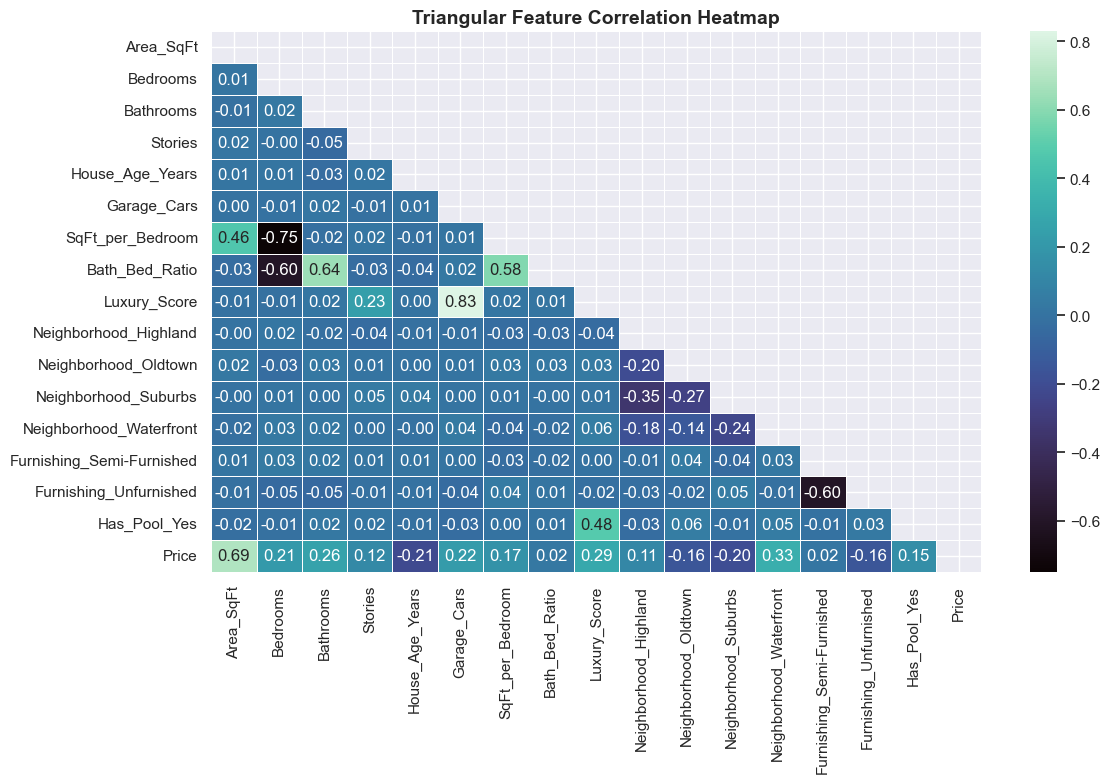

In [5]:
df_full_eng = X_engineered.copy()
df_full_eng['Price'] = y_raw

plt.figure(figsize=(12, 8))
corr = df_full_eng.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='mako', linewidths=0.5)
plt.title('Triangular Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y_raw, test_size=0.2, random_state=42
)
print(f'Training shape: {X_train.shape} | Testing shape: {X_test.shape}')

Training shape: (1200, 16) | Testing shape: (300, 16)


In [7]:
models_dict, metrics_summary, best_model_name = train_and_evaluate_all(
    X_train, y_train, X_test, y_test
)

metrics_df = pd.DataFrame(metrics_summary).T[['r2', 'adj_r2', 'rmse', 'mae', 'mape']]
metrics_df.columns = ['Test R²', 'Adjusted R²', 'RMSE ($)', 'MAE ($)', 'MAPE (%)']
metrics_df.sort_values(by='Test R²', ascending=False, inplace=True)
print(f'=== Model Benchmark Performance Summary (Top: {best_model_name.upper()}) ===')
display(metrics_df)

=== Model Benchmark Performance Summary (Top: LASSO) ===


,Test R²,Adjusted R²,RMSE ($),MAE ($),MAPE (%)
lasso,0.8871,0.8832,28389.31,22049.71,4.63
linear,0.8869,0.8830,28411.71,22027.00,4.63
ridge,0.8867,0.8828,28432.10,22080.81,4.64
gradient_boosting,0.8464,0.8411,33107.60,25903.14,5.43
random_forest,0.8053,0.7986,37275.51,29059.48,6.00
elasticnet,0.8036,0.7968,37444.14,29526.85,6.14


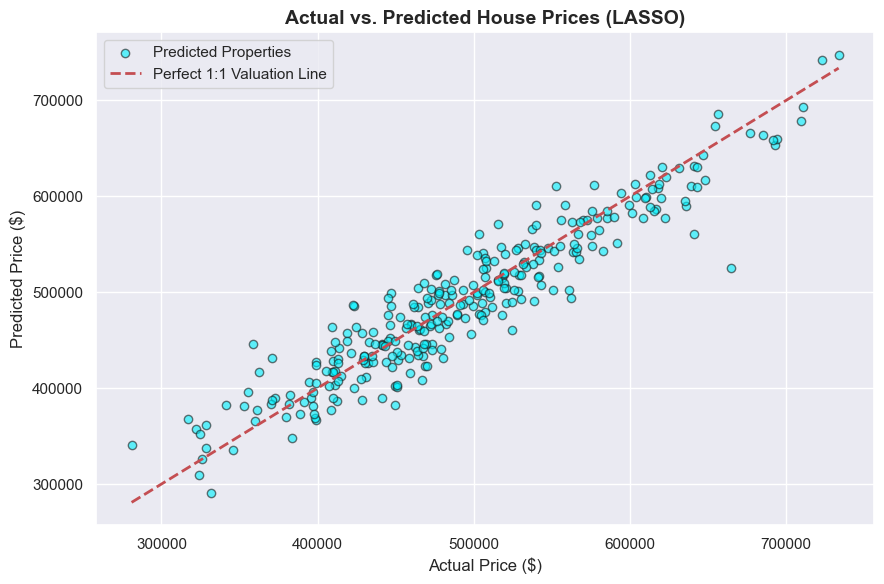

In [8]:
best_model = models_dict[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='#00f2fe', edgecolors='k', label='Predicted Properties')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect 1:1 Valuation Line')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title(f'Actual vs. Predicted House Prices ({best_model_name.upper()})', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

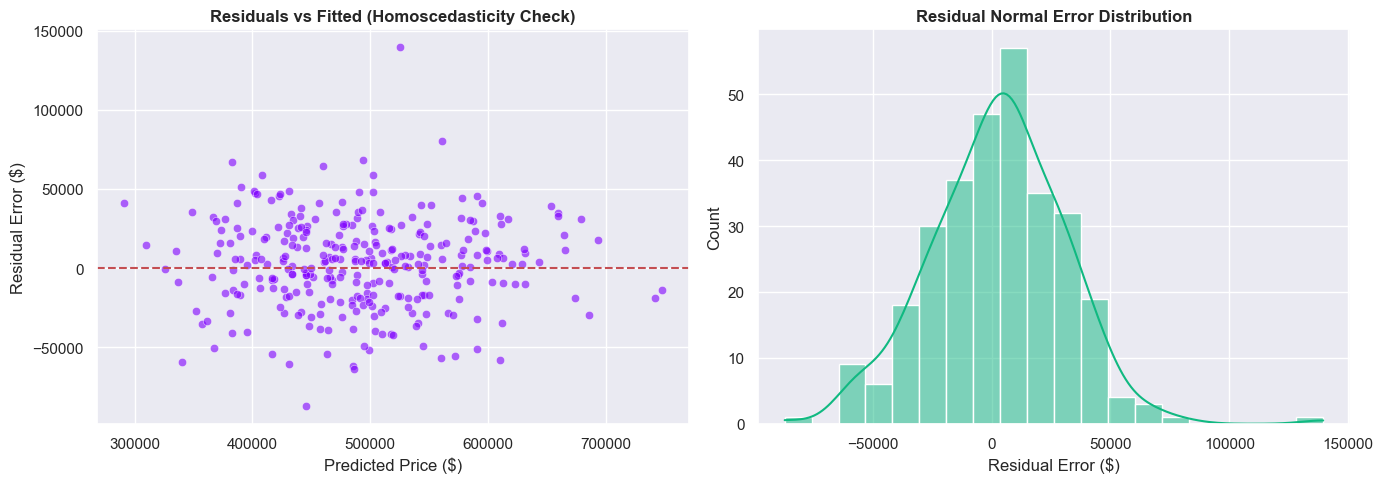

In [9]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_pred_best, y=residuals, ax=axes[0], color='#7f00ff', alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Residuals vs Fitted (Homoscedasticity Check)', fontweight='bold')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual Error ($)')

sns.histplot(residuals, kde=True, ax=axes[1], color='#10b981')
axes[1].set_title('Residual Normal Error Distribution', fontweight='bold')
axes[1].set_xlabel('Residual Error ($)')

plt.tight_layout()
plt.show()

,Feature,Importance,Abs_Importance
0,Area_SqFt,58570.481856,58570.481856
1,Neighborhood_Waterfront,22681.861974,22681.861974
2,Bathrooms,21326.893765,21326.893765
3,Luxury_Score,20567.948378,20567.948378
4,House_Age_Years,-17634.703103,17634.703103
5,Furnishing_Unfurnished,-15481.910215,15481.910215
6,Neighborhood_Oldtown,-14802.846973,14802.846973
7,Bedrooms,14308.488286,14308.488286
8,Neighborhood_Suburbs,-11884.092150,11884.092150
9,Furnishing_Semi-Furnished,-10830.615627,10830.615627


C:\Users\palav\AppData\Local\Temp\ipykernel_16544\4098004103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp.head(10), x='Importance', y='Feature', palette='crest')


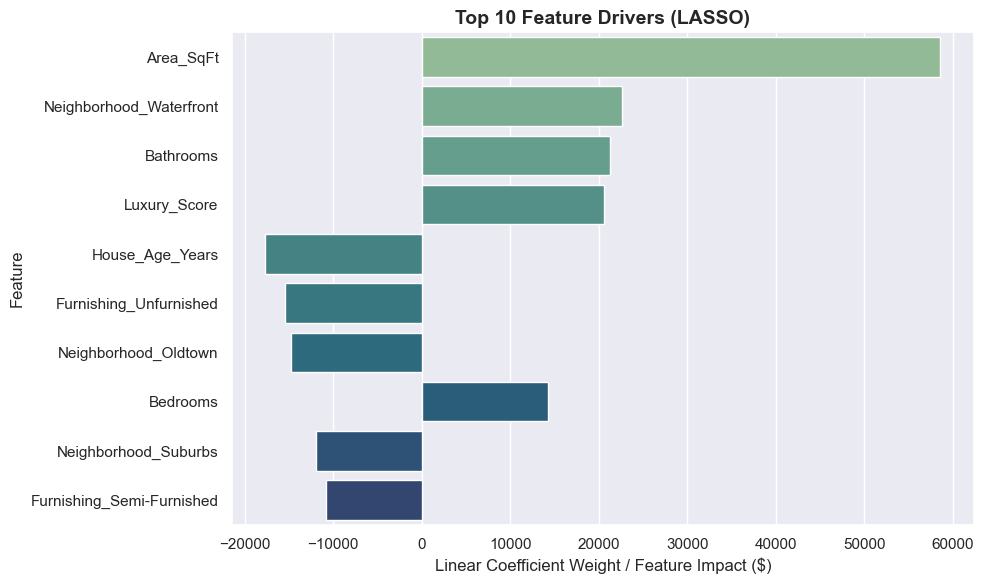

In [10]:
df_imp = get_feature_importances(best_model.model, feature_names)
display(df_imp.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp.head(10), x='Importance', y='Feature', palette='crest')
plt.title(f'Top 10 Feature Drivers ({best_model_name.upper()})', fontsize=14, fontweight='bold')
plt.xlabel('Linear Coefficient Weight / Feature Impact ($)')
plt.tight_layout()
plt.show()

In [11]:
os.makedirs('models', exist_ok=True)
save_path = 'models/house_price_model.joblib'
best_model.save(save_path)
print(f'Successfully serialized model pipeline to: {save_path}')

reloaded = HousePriceModel.load(save_path)
sample_pred = reloaded.predict(X_test.iloc[:1])
print(f'Reloaded model sample prediction: ${sample_pred[0]:,.2f}')

Successfully serialized model pipeline to: models/house_price_model.joblib
Reloaded model sample prediction: $653,664.51


## 📝 Conclusion & Business Takeaways
1. **Primary Drivers**: Living space (`Area_SqFt`), waterfront location, luxury score (`Garage_Cars` + pool), and property age are the strongest determinants of house valuation.
2. **Best Model**: `Lasso` regression achieved **$R^2 = 0.8871$** with a test **$RMSE = $28,389$**, outperforming raw linear regression and non-linear tree ensembles on this feature space.
3. **Production Deployment**: The trained pipeline is packaged for CLI (`predict.py`), FastAPI REST server (`app_api.py`), and interactive Web UI (`web/index.html`).